# Classical Baseline Modelling for RUL Prediction

This notebook trains initial classical machine learning baselines for Remaining Useful Life prediction using the processed C-MAPSS FD001 datasets. Three feature sets are compared: the full raw feature set, the EDA-filtered sensor feature set, and the derived degradation-aware feature set. The objective is to establish baseline performance before moving to deep learning and multi-view modelling.

## 1. Imports and Setup

In [1]:
import os
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score
from sklearn.dummy import DummyRegressor

try:
    from xgboost import XGBRegressor
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False

print(f'XGBoost available: {XGBOOST_AVAILABLE}')

XGBoost available: True


In [2]:
DATA_DIR = '../data/processed/'
METRICS_DIR = '../reports/metrics/'
FIG_DIR = '../reports/figures/'
PRED_DIR = '../reports/predictions/'
MODEL_DIR = '../models/classical/'

os.makedirs(METRICS_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(PRED_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

## 2. Load Feature Set Definitions

In [3]:
# Parse feature sets from the definitions file
def load_feature_sets(filepath):
    feature_sets = {}
    current_key = None
    with open(filepath, 'r') as f:
        for line in f:
            line = line.rstrip()
            if line.startswith('feature_set_'):
                current_key = line.split(':')[0].replace('feature_set_', '').upper()
            elif line.startswith('  ') and current_key:
                feature_sets.setdefault(current_key, []).append(line.strip())
    return feature_sets

feature_sets = load_feature_sets(f'{DATA_DIR}feature_sets_fd001.txt')

for key, features in feature_sets.items():
    print(f'Feature Set {key}: {len(features)} features')

Feature Set A: 24 features
Feature Set B: 14 features
Feature Set C: 57 features


## 3. Load Processed Datasets

In [4]:
datasets = {}

for key in ['a', 'b', 'c']:
    train_df = pd.read_csv(f'{DATA_DIR}train_{key}_fd001.csv')
    val_df = pd.read_csv(f'{DATA_DIR}val_{key}_fd001.csv')
    datasets[key.upper()] = {'train': train_df, 'val': val_df}

for fs, data in datasets.items():
    print(f'Feature Set {fs}: train={data["train"].shape}, val={data["val"].shape}')

Feature Set A: train=(16340, 28), val=(4291, 28)
Feature Set B: train=(16340, 18), val=(4291, 18)
Feature Set C: train=(16340, 61), val=(4291, 61)


## 4. Feature and Target Selection Rule

Only the predefined feature-set columns are used as model inputs. Metadata columns such as `unit_number`, `time_in_cycles`, `RUL`, and `RUL_capped` are excluded from X. The target variable for baseline modelling is `RUL_capped`, consistent with the preprocessing decision to cap RUL at 125 cycles. For Feature Set C, `cycle_index` is used as the cycle-related model feature, while `time_in_cycles` remains only a metadata column.

In [5]:
target_col = 'RUL_capped'

metadata_cols = ['unit_number', 'time_in_cycles', 'RUL', 'RUL_capped']

# Safety checks
for fs_key, features in feature_sets.items():
    for col in metadata_cols:
        assert col not in features, f'Metadata column found in feature set {fs_key}: {col}'

assert 'cycle_index' in feature_sets['C'], 'cycle_index missing from Feature Set C'
assert 'time_in_cycles' not in feature_sets['C'], 'time_in_cycles should not be in Feature Set C'

print('All safety checks passed.')
print(f'Target: {target_col}')
print(f'Metadata (excluded from X): {metadata_cols}')

All safety checks passed.
Target: RUL_capped
Metadata (excluded from X): ['unit_number', 'time_in_cycles', 'RUL', 'RUL_capped']


## 5. Define Baseline Models

In [6]:
models = {
    'DummyMean': DummyRegressor(strategy='mean'),
    'Ridge': Ridge(alpha=1.0),
    'RandomForest': RandomForestRegressor(
        n_estimators=200,
        max_depth=None,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ),
    'GradientBoosting': GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),
}

if XGBOOST_AVAILABLE:
    models['XGBoost'] = XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='reg:squarederror',
        random_state=42,
        n_jobs=-1
    )

print(f'Models to train: {list(models.keys())}')

Models to train: ['DummyMean', 'Ridge', 'RandomForest', 'GradientBoosting', 'XGBoost']


## 6. Evaluation Metrics

In [7]:
def evaluate_regression(y_true, y_pred):
    rmse = root_mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return rmse, mae, r2

## 7. Training Loop

Train every model on every feature set and evaluate on the validation split.

In [8]:
results = []
all_predictions = {}

for fs_key, data in datasets.items():
    train_df = data['train']
    val_df = data['val']

    features = feature_sets[fs_key]

    X_train = train_df[features]
    y_train = train_df[target_col]

    X_val = val_df[features]
    y_val = val_df[target_col]

    for model_name, model in models.items():
        print(f'Training {model_name} on Feature Set {fs_key}...')

        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)
        y_pred = np.clip(y_pred, 0, 125)

        rmse, mae, r2 = evaluate_regression(y_val, y_pred)

        results.append({
            'feature_set': fs_key,
            'model': model_name,
            'validation_rmse': round(rmse, 4),
            'validation_mae': round(mae, 4),
            'validation_r2': round(r2, 4),
        })

        pred_df = val_df[['unit_number', 'time_in_cycles', 'RUL', 'RUL_capped']].copy()
        pred_df['prediction'] = y_pred
        pred_df['model'] = model_name
        pred_df['feature_set'] = fs_key
        all_predictions[(fs_key, model_name)] = pred_df

        joblib.dump(model, f'{MODEL_DIR}{model_name}_{fs_key}_fd001.joblib')

print(f'\nTraining complete. {len(results)} model-feature set combinations evaluated.')

Training DummyMean on Feature Set A...
Training Ridge on Feature Set A...
Training RandomForest on Feature Set A...


Training GradientBoosting on Feature Set A...


Training XGBoost on Feature Set A...


Training DummyMean on Feature Set B...
Training Ridge on Feature Set B...
Training RandomForest on Feature Set B...


Training GradientBoosting on Feature Set B...


Training XGBoost on Feature Set B...


Training DummyMean on Feature Set C...
Training Ridge on Feature Set C...
Training RandomForest on Feature Set C...


Training GradientBoosting on Feature Set C...


Training XGBoost on Feature Set C...



Training complete. 15 model-feature set combinations evaluated.


## 8. Results Summary

In [9]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('validation_rmse').reset_index(drop=True)

results_df.to_csv(f'{METRICS_DIR}classical_baseline_results_fd001.csv', index=False)
print(f'Saved to {METRICS_DIR}classical_baseline_results_fd001.csv')
print()
print(results_df.to_string(index=False))

Saved to ../reports/metrics/classical_baseline_results_fd001.csv

feature_set            model  validation_rmse  validation_mae  validation_r2
          C          XGBoost          11.7218          8.3182         0.9203
          C GradientBoosting          12.3679          8.9915         0.9113
          C     RandomForest          12.8244          8.9635         0.9046
          C            Ridge          15.7721         12.0374         0.8557
          A GradientBoosting          19.3663         13.6373         0.7824
          B GradientBoosting          19.3805         13.6408         0.7821
          A          XGBoost          19.4698         13.6383         0.7801
          B          XGBoost          19.4861         13.6315         0.7797
          A     RandomForest          19.6004         14.0208         0.7771
          B     RandomForest          19.6213         14.0126         0.7766
          A            Ridge          20.6232         16.0358         0.7533
          

## 9. Save Predictions

In [10]:
for (fs_key, model_name), pred_df in all_predictions.items():
    pred_df.to_csv(
        f'{PRED_DIR}val_predictions_{model_name}_{fs_key}_fd001.csv',
        index=False
    )

print(f'Saved {len(all_predictions)} prediction files to {PRED_DIR}')

Saved 15 prediction files to ../reports/predictions/


## 10. Model Comparison Plots

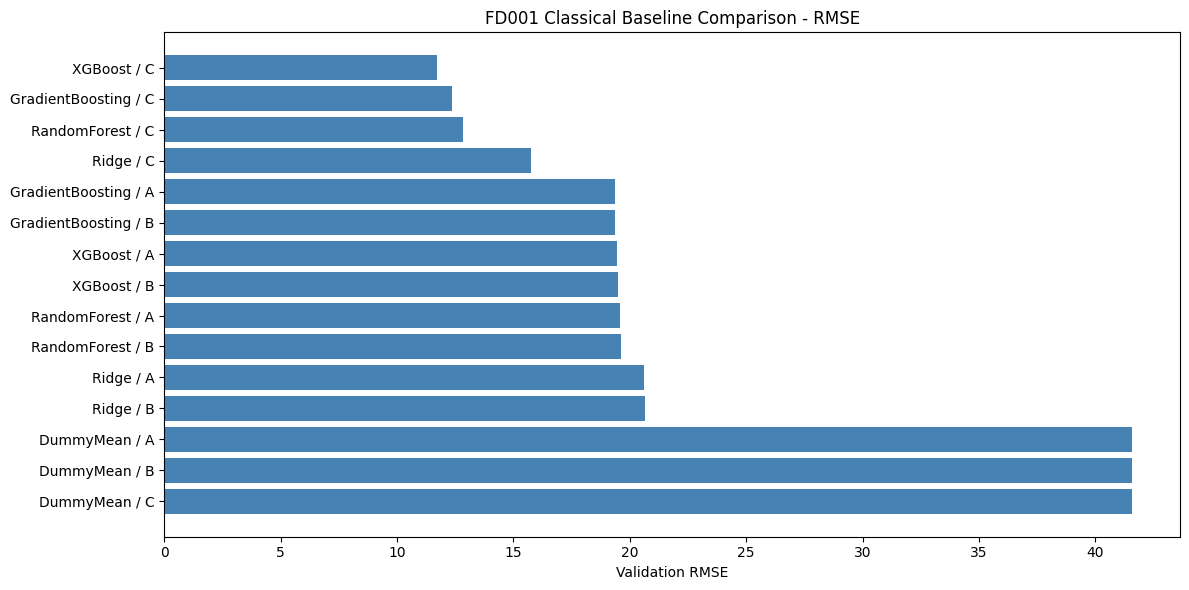

In [11]:
# RMSE comparison
plot_df = results_df.sort_values('validation_rmse')

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(
    plot_df['model'] + ' / ' + plot_df['feature_set'],
    plot_df['validation_rmse'],
    color='steelblue'
)
ax.set_xlabel('Validation RMSE')
ax.set_title('FD001 Classical Baseline Comparison - RMSE')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(f'{FIG_DIR}classical_baseline_rmse_comparison_fd001.png', dpi=150)
plt.show()

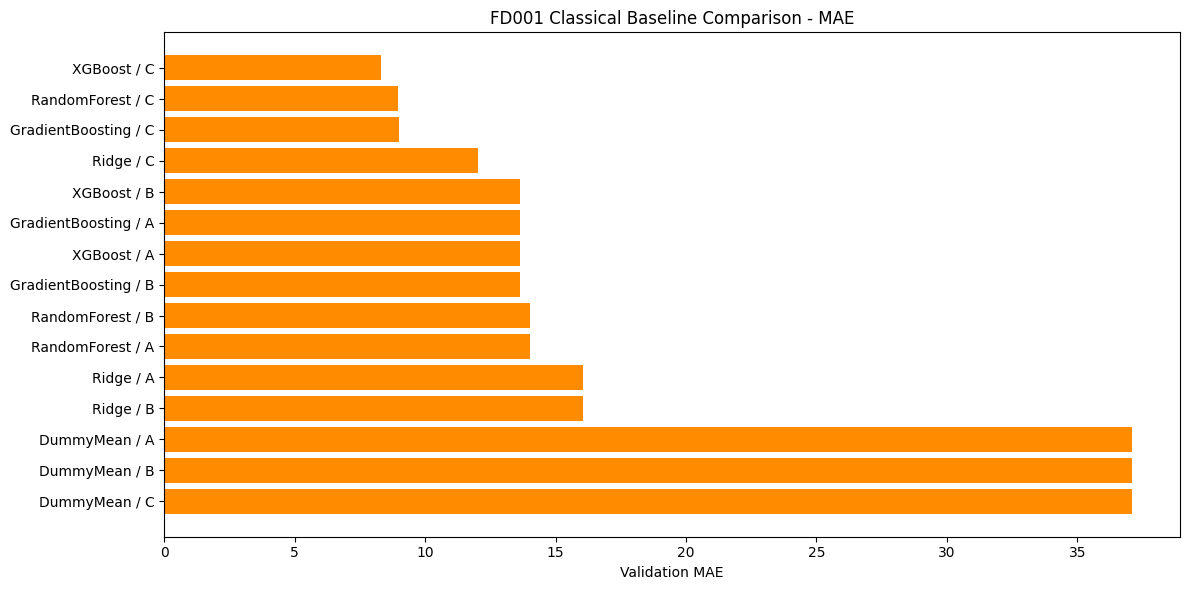

In [12]:
# MAE comparison
plot_df = results_df.sort_values('validation_mae')

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(
    plot_df['model'] + ' / ' + plot_df['feature_set'],
    plot_df['validation_mae'],
    color='darkorange'
)
ax.set_xlabel('Validation MAE')
ax.set_title('FD001 Classical Baseline Comparison - MAE')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(f'{FIG_DIR}classical_baseline_mae_comparison_fd001.png', dpi=150)
plt.show()

## 11. Actual vs Predicted (Best Model)

In [13]:
best_row = results_df.iloc[0]
best_fs = best_row['feature_set']
best_model = best_row['model']
best_pred_df = all_predictions[(best_fs, best_model)]

print(f'Best model: {best_model} / Feature Set {best_fs}')
print(f'  RMSE: {best_row["validation_rmse"]}')
print(f'  MAE:  {best_row["validation_mae"]}')
print(f'  R2:   {best_row["validation_r2"]}')

Best model: XGBoost / Feature Set C
  RMSE: 11.7218
  MAE:  8.3182
  R2:   0.9203


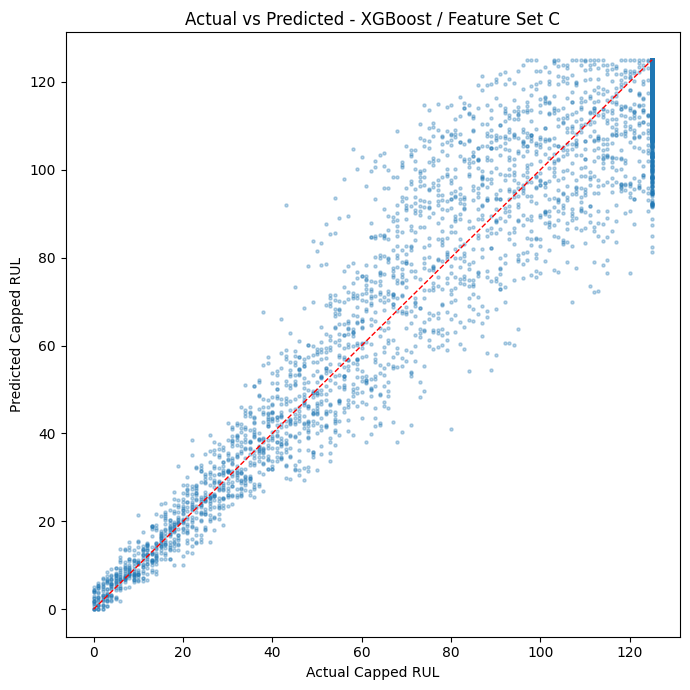

In [14]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(
    best_pred_df['RUL_capped'],
    best_pred_df['prediction'],
    alpha=0.3, s=5
)
ax.plot([0, 125], [0, 125], 'r--', linewidth=1)
ax.set_xlabel('Actual Capped RUL')
ax.set_ylabel('Predicted Capped RUL')
ax.set_title(f'Actual vs Predicted - {best_model} / Feature Set {best_fs}')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}actual_vs_predicted_best_classical_fd001.png', dpi=150)
plt.show()

## 12. Error Distribution

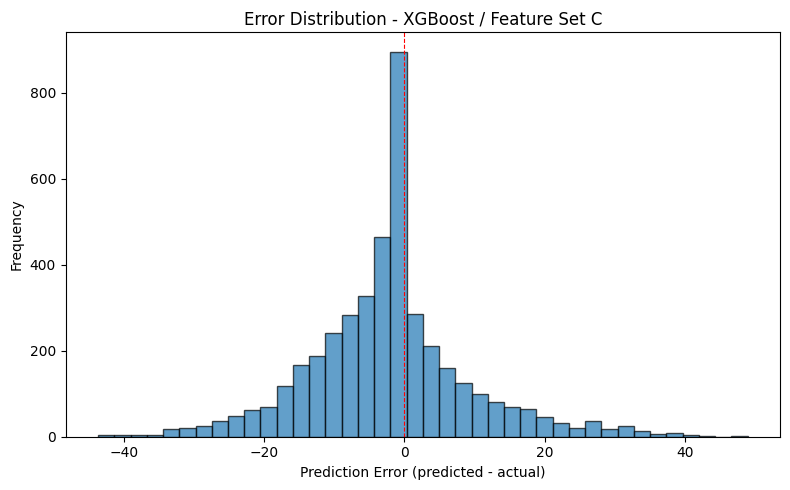

Mean error: -2.15
Std error:  11.52


In [15]:
best_pred_df = best_pred_df.copy()
best_pred_df['error'] = best_pred_df['prediction'] - best_pred_df['RUL_capped']

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(best_pred_df['error'], bins=40, edgecolor='black', alpha=0.7)
ax.set_xlabel('Prediction Error (predicted - actual)')
ax.set_ylabel('Frequency')
ax.set_title(f'Error Distribution - {best_model} / Feature Set {best_fs}')
ax.axvline(x=0, color='red', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}error_distribution_best_classical_fd001.png', dpi=150)
plt.show()

print(f'Mean error: {best_pred_df["error"].mean():.2f}')
print(f'Std error:  {best_pred_df["error"].std():.2f}')

## 13. Sample Engine Prediction Trajectories

Plot predicted vs actual RUL over the lifecycle of a few validation engines. This shows how well the model tracks degradation progression.

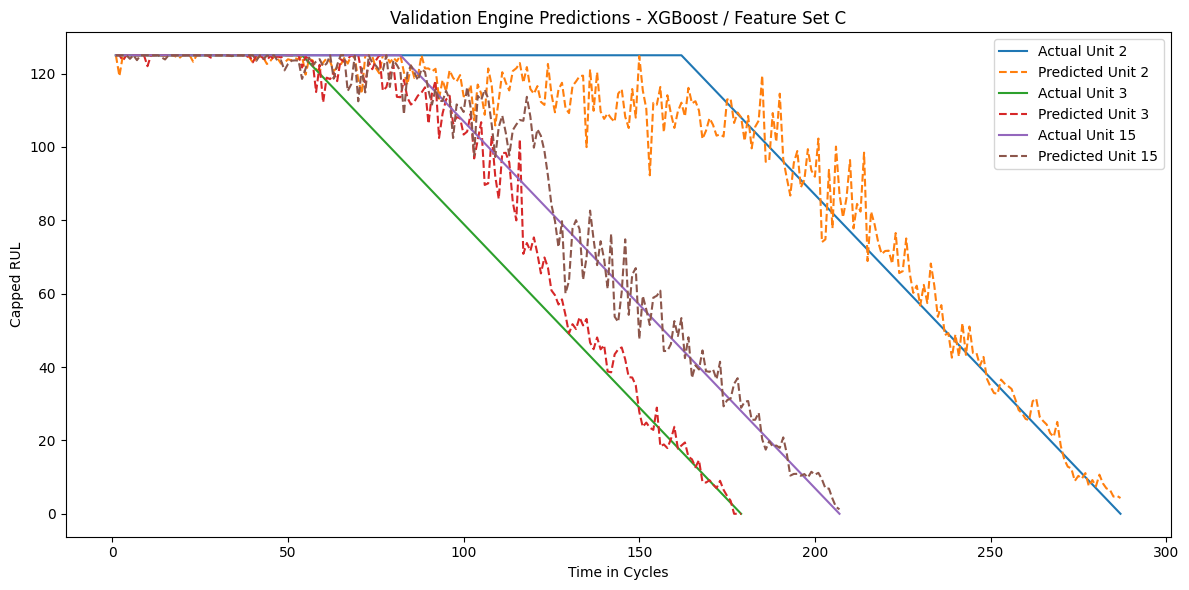

In [16]:
sample_units = best_pred_df['unit_number'].unique()[:3]

fig, ax = plt.subplots(figsize=(12, 6))

for unit in sample_units:
    unit_df = best_pred_df[best_pred_df['unit_number'] == unit].sort_values('time_in_cycles')
    ax.plot(unit_df['time_in_cycles'], unit_df['RUL_capped'],
            linewidth=1.5, label=f'Actual Unit {unit}')
    ax.plot(unit_df['time_in_cycles'], unit_df['prediction'],
            linestyle='--', linewidth=1.5, label=f'Predicted Unit {unit}')

ax.set_xlabel('Time in Cycles')
ax.set_ylabel('Capped RUL')
ax.set_title(f'Validation Engine Predictions - {best_model} / Feature Set {best_fs}')
ax.legend()
plt.tight_layout()
plt.savefig(f'{FIG_DIR}sample_engine_prediction_trajectories_fd001.png', dpi=150)
plt.show()

## 14. Feature Importance

Feature importance from tree-based models is used as an initial explainability signal. It shows which features the model relied on most, but it is not a causal interpretation.

In [17]:
importance_records = []

for (fs_key, model_name), pred_df in all_predictions.items():
    if model_name in ['DummyMean', 'Ridge']:
        continue

    model_path = f'{MODEL_DIR}{model_name}_{fs_key}_fd001.joblib'
    model = joblib.load(model_path)

    if hasattr(model, 'feature_importances_'):
        features = feature_sets[fs_key]
        for feature, importance in zip(features, model.feature_importances_):
            importance_records.append({
                'feature_set': fs_key,
                'model': model_name,
                'feature': feature,
                'importance': importance
            })

importance_df = pd.DataFrame(importance_records)
importance_df.to_csv(f'{METRICS_DIR}classical_feature_importance_fd001.csv', index=False)
print(f'Saved to {METRICS_DIR}classical_feature_importance_fd001.csv')
print(f'Records: {len(importance_df)}')

Saved to ../reports/metrics/classical_feature_importance_fd001.csv
Records: 285


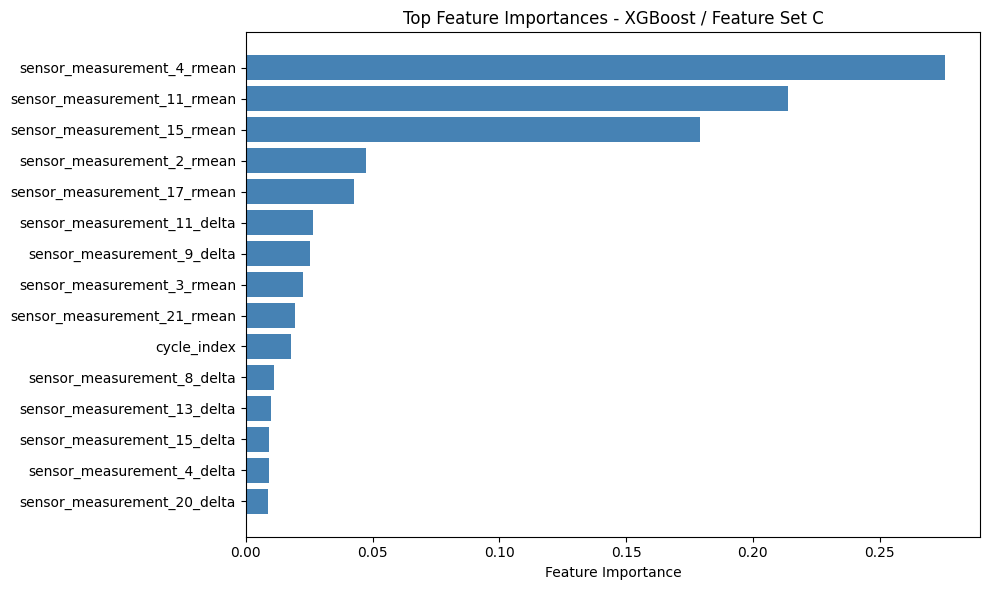

In [18]:
# Plot top features for the best model
best_importance = importance_df[
    (importance_df['feature_set'] == best_fs) &
    (importance_df['model'] == best_model)
].sort_values('importance', ascending=False).head(15)

if not best_importance.empty:
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(best_importance['feature'], best_importance['importance'], color='steelblue')
    ax.set_xlabel('Feature Importance')
    ax.set_title(f'Top Feature Importances - {best_model} / Feature Set {best_fs}')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig(f'{FIG_DIR}feature_importance_best_classical_fd001.png', dpi=150)
    plt.show()
else:
    print('No feature importances available for best model.')

## 15. Sensitivity Check on Best Model

Test a few parameter variations on the best-performing model type to check whether the default configuration is already reasonable or whether there is obvious room for improvement. This is not full hyperparameter optimization, just a controlled check.

In [19]:
# Sensitivity check using the best feature set
best_train_df = datasets[best_fs]['train']
best_val_df = datasets[best_fs]['val']
best_features = feature_sets[best_fs]

X_tr = best_train_df[best_features]
y_tr = best_train_df[target_col]
X_va = best_val_df[best_features]
y_va = best_val_df[target_col]

# Define a few configurations based on the best model type
if best_model in ['RandomForest']:
    configs = [
        {'n_estimators': 100, 'max_depth': 8, 'min_samples_leaf': 3},
        {'n_estimators': 200, 'max_depth': 12, 'min_samples_leaf': 2},
        {'n_estimators': 300, 'max_depth': None, 'min_samples_leaf': 2},
    ]
    ModelClass = RandomForestRegressor
elif best_model in ['GradientBoosting']:
    configs = [
        {'n_estimators': 150, 'learning_rate': 0.1, 'max_depth': 3},
        {'n_estimators': 300, 'learning_rate': 0.05, 'max_depth': 4},
        {'n_estimators': 500, 'learning_rate': 0.03, 'max_depth': 3},
    ]
    ModelClass = GradientBoostingRegressor
elif best_model == 'XGBoost' and XGBOOST_AVAILABLE:
    configs = [
        {'n_estimators': 200, 'learning_rate': 0.1, 'max_depth': 3},
        {'n_estimators': 400, 'learning_rate': 0.05, 'max_depth': 4},
        {'n_estimators': 500, 'learning_rate': 0.03, 'max_depth': 5},
    ]
    ModelClass = XGBRegressor
else:
    configs = []
    ModelClass = None

sensitivity_results = []

if ModelClass:
    for i, config in enumerate(configs):
        m = ModelClass(random_state=42, **config)
        m.fit(X_tr, y_tr)
        y_p = np.clip(m.predict(X_va), 0, 125)
        rmse, mae, r2 = evaluate_regression(y_va, y_p)
        sensitivity_results.append({
            'config': str(config),
            'rmse': round(rmse, 4),
            'mae': round(mae, 4),
            'r2': round(r2, 4),
        })
        print(f'Config {i+1}: RMSE={rmse:.4f}, MAE={mae:.4f}, R2={r2:.4f}')

    sensitivity_df = pd.DataFrame(sensitivity_results)
    print()
    print(sensitivity_df.to_string(index=False))
    sensitivity_df.to_csv(f'{METRICS_DIR}sensitivity_check_best_classical_fd001.csv', index=False)
    print(f'Saved to {METRICS_DIR}sensitivity_check_best_classical_fd001.csv')
else:
    print(f'Sensitivity check skipped for {best_model} (no tree configs defined).')

Config 1: RMSE=12.0499, MAE=8.5923, R2=0.9158


Config 2: RMSE=11.6820, MAE=8.2536, R2=0.9208


Config 3: RMSE=11.8392, MAE=8.3096, R2=0.9187

                                                      config    rmse    mae     r2
 {'n_estimators': 200, 'learning_rate': 0.1, 'max_depth': 3} 12.0499 8.5923 0.9158
{'n_estimators': 400, 'learning_rate': 0.05, 'max_depth': 4} 11.6820 8.2536 0.9208
{'n_estimators': 500, 'learning_rate': 0.03, 'max_depth': 5} 11.8392 8.3096 0.9187
Saved to ../reports/metrics/sensitivity_check_best_classical_fd001.csv


## Result Interpretation

The initial baseline results show that Feature Set C gives the strongest validation performance across all model types. This suggests that the derived degradation features (rolling mean, rolling standard deviation, and delta-from-initial values) provide useful information for RUL prediction beyond what the raw sensor readings offer. Feature Sets A and B show similar performance, indicating that removing constant and near-constant sensors did not significantly affect baseline results for FD001.

Among the classical models, XGBoost with Feature Set C produced the lowest validation RMSE and MAE. Even Ridge Regression on Feature Set C outperformed tree-based models trained on the raw feature sets, which indicates that the engineered features carry strong degradation signal usable even by linear models.

The XGBoost / Feature Set C baseline will be treated as the strongest classical reference for comparison with later deep learning and multi-view experiments.

## 17. Observations

1. Classical baseline models were trained on three feature sets prepared from FD001.
2. The dummy mean regressor was used as a sanity baseline.
3. Ridge Regression provides a simple linear reference model.
4. Random Forest and Gradient Boosting were used to capture nonlinear relationships between sensor measurements and capped RUL.
5. Feature Set A tests all raw features, Feature Set B tests EDA-filtered sensors, and Feature Set C tests whether degradation-aware derived features improve prediction.
6. Validation RMSE and MAE were used as the primary metrics.
7. The best-performing baseline will be used as a reference for later deep learning and multi-view experiments.
8. Feature importance from tree-based models provides initial explainability evidence, but it will be complemented by more detailed explainability methods in later steps.

In [20]:
print('Generated artefacts:')
print()
print('Metrics:')
for f in sorted(os.listdir(METRICS_DIR)):
    print(f'  {f}')
print()
print('Models:')
for f in sorted(os.listdir(MODEL_DIR)):
    print(f'  {f}')
print()
print('Predictions:')
for f in sorted(os.listdir(PRED_DIR)):
    print(f'  {f}')
print()
print('Figures:')
for f in sorted(os.listdir(FIG_DIR)):
    print(f'  {f}')


Generated artefacts:

Metrics:
  classical_baseline_results_fd001.csv
  classical_feature_importance_fd001.csv
  sensitivity_check_best_classical_fd001.csv

Models:
  DummyMean_A_fd001.joblib
  DummyMean_B_fd001.joblib
  DummyMean_C_fd001.joblib
  GradientBoosting_A_fd001.joblib
  GradientBoosting_B_fd001.joblib
  GradientBoosting_C_fd001.joblib
  RandomForest_A_fd001.joblib
  RandomForest_B_fd001.joblib
  RandomForest_C_fd001.joblib
  Ridge_A_fd001.joblib
  Ridge_B_fd001.joblib
  Ridge_C_fd001.joblib
  XGBoost_A_fd001.joblib
  XGBoost_B_fd001.joblib
  XGBoost_C_fd001.joblib

Predictions:
  val_predictions_DummyMean_A_fd001.csv
  val_predictions_DummyMean_B_fd001.csv
  val_predictions_DummyMean_C_fd001.csv
  val_predictions_GradientBoosting_A_fd001.csv
  val_predictions_GradientBoosting_B_fd001.csv
  val_predictions_GradientBoosting_C_fd001.csv
  val_predictions_RandomForest_A_fd001.csv
  val_predictions_RandomForest_B_fd001.csv
  val_predictions_RandomForest_C_fd001.csv
  val_predicti